In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import FashionMNIST, MNIST
from torchvision.utils import save_image

# Pad 28x28 -> 32x32 with a 2-pixel black border (PIL fill=0 by default),
# then to tensor in [0, 1] and normalize to [-1, 1] (matches Tanh generator output).
gan_transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# Auto-downloads on first run to ./data/<Name>/raw/. Subsequent runs are cached.
fashion_train_ds = FashionMNIST(root="./data", train=True,  download=True,
                                transform=gan_transform)
fashion_test_ds  = FashionMNIST(root="./data", train=False, download=True,
                                transform=gan_transform)
mnist_train_ds   = MNIST(root="./data",        train=True,  download=True,
                         transform=gan_transform)
mnist_test_ds    = MNIST(root="./data",        train=False, download=True,
                         transform=gan_transform)

In [ ]:
# DCGAN-style critic for 32x32 grayscale. Spatial halves each conv layer:
# 32 -> 16 -> 8 -> 4 -> 1. No BatchNorm on first layer; no output activation
# (LSGAN uses MSE directly on raw scores).
class Discriminator(nn.Module):
    def __init__(self, ndf=64, num_channels=1):
        super().__init__()
        self.net = nn.Sequential(
            # 32x32 -> 16x16
            nn.Conv2d(num_channels, ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 16x16 -> 8x8
            nn.Conv2d(ndf, ndf*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),
            # 8x8 -> 4x4
            nn.Conv2d(ndf*2, ndf*4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),
            # 4x4 -> 1x1
            nn.Conv2d(ndf*4, 1, kernel_size=4, stride=1, padding=0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
# DCGAN-style generator: latent vector -> 32x32 image. Spatial doubles each
# transpose-conv: 1 -> 4 -> 8 -> 16 -> 32. Tanh output maps to [-1, 1] which
# matches Normalize((0.5,), (0.5,)) on the real data side.
class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64, num_channels=1):
        super().__init__()
        self.net = nn.Sequential(
            # 1x1 -> 4x4
            nn.ConvTranspose2d(latent_dim, ngf*4, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(inplace=True),
            # 4x4 -> 8x8
            nn.ConvTranspose2d(ngf*4, ngf*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(inplace=True),
            # 8x8 -> 16x16
            nn.ConvTranspose2d(ngf*2, ngf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(inplace=True),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(ngf, num_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        # Accept either [B, latent_dim] or [B, latent_dim, 1, 1]
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)

In [ ]:
# Datasets are defined in cell 0 with a shared transform pipeline.
# FashionMNIST: 60k train / 10k test, 10 clothing classes.
# MNIST: 60k train / 10k test, 10 handwritten digit classes.
# Both are 28x28 grayscale, padded to 32x32 here.

In [ ]:
def initialize_weights(model):
    # Initializes weights according to the DCGAN paper
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

In [ ]:
# Architecture
LATENT_DIM   = 100
NGF          = 64
NDF          = 64
IMAGE_SIZE   = 32
NUM_CHANNELS = 1

# Training
BATCH_SIZE   = 128
NUM_EPOCHS   = 30
LR           = 2e-4
BETA1        = 0.5
BETA2        = 0.999

# Logging / checkpointing
SAMPLE_EVERY_EPOCH = 1   # save sample grid every N epochs
CHECKPOINT_EVERY   = 5   # save G/D weights every N epochs

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [ ]:
fashion_train_dl = DataLoader(fashion_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, drop_last=True)
fashion_test_dl  = DataLoader(fashion_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0)
mnist_train_dl   = DataLoader(mnist_train_ds,   batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, drop_last=True)
mnist_test_dl    = DataLoader(mnist_test_ds,    batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0)

device: mps
Batch shape: torch.Size([128, 1, 32, 32])  range: [-1.00, 1.00]


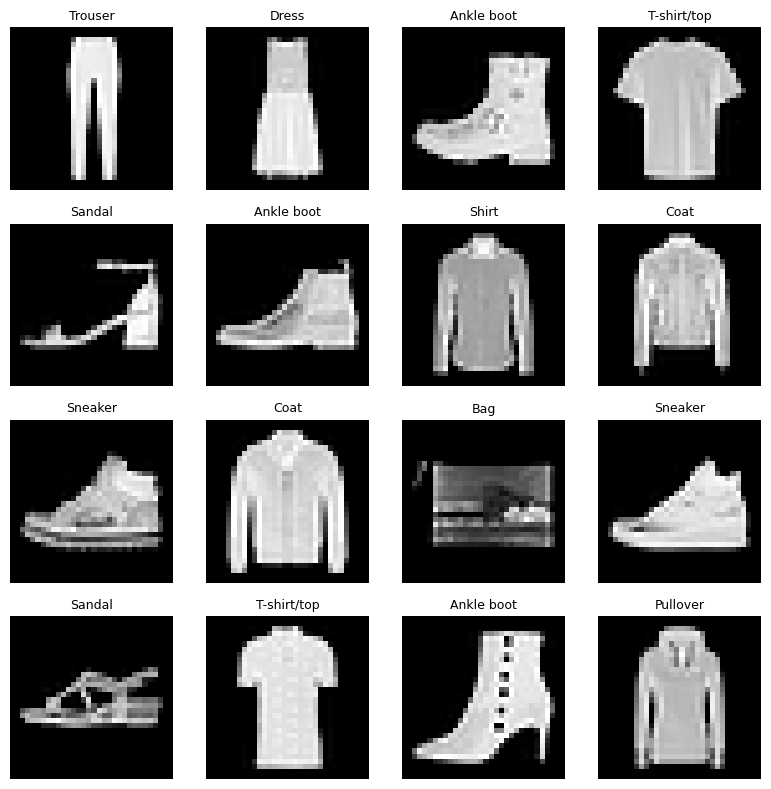

In [ ]:
if __name__ == "__main__":
    xb, yb = next(iter(fashion_train_dl))
    print(f"device: {device}")
    print(f"Batch shape: {xb.shape}  range: [{xb.min():.2f}, {xb.max():.2f}]")

    # Undo normalization for display ([-1,1] -> [0,1]), then show a 4x4 thumbnail grid.
    xb_display = xb * 0.5 + 0.5
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for ax, img, label in zip(axes.flat, xb_display[:16], yb[:16]):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_title(fashion_train_ds.classes[label], fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
def make_models():
    G = Generator(latent_dim=LATENT_DIM, ngf=NGF, num_channels=NUM_CHANNELS).to(device)
    D = Discriminator(ndf=NDF, num_channels=NUM_CHANNELS).to(device)
    G.apply(initialize_weights)
    D.apply(initialize_weights)
    return G, D

In [ ]:
# Optimizers + fixed_z are created per-run inside train_lsgan() so each
# dataset run starts fresh. The MSE criterion (the "LS" in LSGAN) is shared.
criterion = nn.MSELoss()

[fashion] training 30 epochs, 468 batches/epoch on mps
[fashion] G params: 1,066,880  D params: 661,248
[fashion] epoch   1/30 | loss_D=0.0188 | loss_G=1.0267 | D(real)=0.943 | D(fake)=0.027
[fashion] epoch   2/30 | loss_D=0.0441 | loss_G=0.9548 | D(real)=0.894 | D(fake)=0.103
[fashion] epoch   3/30 | loss_D=0.0900 | loss_G=0.7920 | D(real)=0.791 | D(fake)=0.205
[fashion] epoch   4/30 | loss_D=0.0948 | loss_G=0.7470 | D(real)=0.781 | D(fake)=0.217
[fashion] epoch   5/30 | loss_D=0.1065 | loss_G=0.6850 | D(real)=0.754 | D(fake)=0.245
[fashion] epoch   6/30 | loss_D=0.1153 | loss_G=0.6644 | D(real)=0.737 | D(fake)=0.261
[fashion] epoch   7/30 | loss_D=0.1564 | loss_G=0.5625 | D(real)=0.669 | D(fake)=0.329
[fashion] epoch   8/30 | loss_D=0.1333 | loss_G=0.6242 | D(real)=0.707 | D(fake)=0.290
[fashion] epoch   9/30 | loss_D=0.1220 | loss_G=0.6291 | D(real)=0.716 | D(fake)=0.283
[fashion] epoch  10/30 | loss_D=0.1247 | loss_G=0.6399 | D(real)=0.718 | D(fake)=0.281
[fashion] epoch  11/30 | l

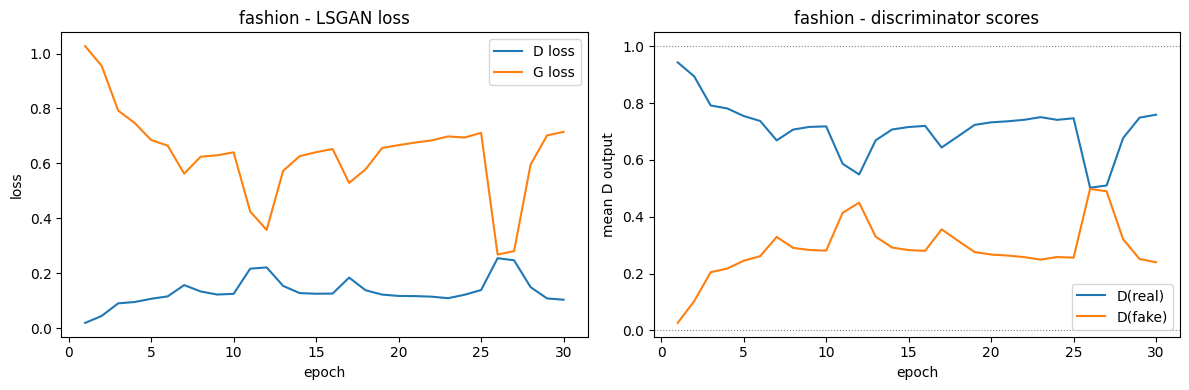

In [ ]:
def train_lsgan(train_dl, name, num_epochs=NUM_EPOCHS):
    """Train an LSGAN on `train_dl`. Saves checkpoints + sample grids under runs/<name>/."""
    out_dir    = Path("runs") / name
    sample_dir = out_dir / "samples"
    ckpt_dir   = out_dir / "checkpoints"
    sample_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    G, D = make_models()
    opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(BETA1, BETA2))
    opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(BETA1, BETA2))

    # Same z used at every sample log -> consistent visual progress over time.
    fixed_z = torch.randn(64, LATENT_DIM, device=device)
    losses  = {"epoch": [], "D": [], "G": [], "D_real": [], "D_fake": []}

    print(f"[{name}] training {num_epochs} epochs, {len(train_dl)} batches/epoch on {device}")
    print(f"[{name}] G params: {sum(p.numel() for p in G.parameters()):,}  "
          f"D params: {sum(p.numel() for p in D.parameters()):,}")

    for epoch in range(1, num_epochs + 1):
        G.train(); D.train()
        running_D, running_G, n = 0.0, 0.0, 0
        d_real_sum, d_fake_sum = 0.0, 0.0

        for real_imgs, _ in train_dl:
            real_imgs   = real_imgs.to(device)
            batch_size  = real_imgs.size(0)
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # ---- Discriminator step ----
            z = torch.randn(batch_size, LATENT_DIM, device=device)
            fake_imgs = G(z)
            d_real = D(real_imgs)
            d_fake = D(fake_imgs.detach())  # detach so G doesn't get D's gradient here
            loss_D = 0.5 * (criterion(d_real, real_labels) +
                            criterion(d_fake, fake_labels))
            opt_D.zero_grad(); loss_D.backward(); opt_D.step()

            # ---- Generator step ----
            d_fake_for_g = D(fake_imgs)
            loss_G = criterion(d_fake_for_g, real_labels)
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()

            running_D  += loss_D.item()
            running_G  += loss_G.item()
            d_real_sum += d_real.mean().item()
            d_fake_sum += d_fake.mean().item()
            n += 1

        losses["epoch"].append(epoch)
        losses["D"].append(running_D / n)
        losses["G"].append(running_G / n)
        losses["D_real"].append(d_real_sum / n)
        losses["D_fake"].append(d_fake_sum / n)
        print(f"[{name}] epoch {epoch:3d}/{num_epochs} | "
              f"loss_D={losses['D'][-1]:.4f} | loss_G={losses['G'][-1]:.4f} | "
              f"D(real)={losses['D_real'][-1]:.3f} | D(fake)={losses['D_fake'][-1]:.3f}")

        # Sample grid (every SAMPLE_EVERY_EPOCH epochs)
        if epoch % SAMPLE_EVERY_EPOCH == 0:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z)
            G.train()
            save_image(samples.cpu() * 0.5 + 0.5,
                       sample_dir / f"epoch_{epoch:03d}.png",
                       nrow=8, padding=2, pad_value=1.0)

        # Periodic checkpoint
        if epoch % CHECKPOINT_EVERY == 0:
            torch.save(G.state_dict(), ckpt_dir / f"G_epoch_{epoch:03d}.pt")
            torch.save(D.state_dict(), ckpt_dir / f"D_epoch_{epoch:03d}.pt")

    # Final save
    torch.save(G.state_dict(), out_dir / "G_final.pt")
    torch.save(D.state_dict(), out_dir / "D_final.pt")
    with open(out_dir / "losses.json", "w") as f:
        json.dump(losses, f, indent=2)

    return G, D, losses


def plot_gan_losses(losses, name):
    """Save loss + discriminator-score curves to runs/<name>/curves.png."""
    epochs = losses["epoch"]
    fig, (ax_loss, ax_score) = plt.subplots(1, 2, figsize=(12, 4))

    ax_loss.plot(epochs, losses["D"], label="D loss")
    ax_loss.plot(epochs, losses["G"], label="G loss")
    ax_loss.set(xlabel="epoch", ylabel="loss", title=f"{name} - LSGAN loss")
    ax_loss.legend()

    ax_score.plot(epochs, losses["D_real"], label="D(real)")
    ax_score.plot(epochs, losses["D_fake"], label="D(fake)")
    ax_score.axhline(1, color="gray", linestyle=":", linewidth=0.8)
    ax_score.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax_score.set(xlabel="epoch", ylabel="mean D output",
                 title=f"{name} - discriminator scores")
    ax_score.legend()

    fig.tight_layout()
    fig.savefig(Path("runs") / name / "curves.png", dpi=120, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    G_fashion, D_fashion, losses_fashion = train_lsgan(fashion_train_dl, "fashion")
    plot_gan_losses(losses_fashion, "fashion")

In [ ]:
# train_lsgan() already saves checkpoints (every CHECKPOINT_EVERY epochs) plus
# G_final.pt / D_final.pt at the end, under runs/<name>/.

In [ ]:
from fid import fid

# fid.py applies ImageNet normalization (mean/std calibrated for inputs in [0,1]),
# so we denormalize from [-1, 1] back to [0, 1] before yielding. FID expands
# 1-channel to 3-channel internally, but we do it here for explicitness.

def generate_samples(N_samples, gen, latent_dim, batch_size=64):
    """Yield generated images as 3-channel tensors in [0, 1]."""
    gen.eval()
    yielded = 0
    with torch.no_grad():
        while yielded < N_samples:
            current = min(batch_size, N_samples - yielded)
            z = torch.randn(current, latent_dim, device=device)
            batch = gen(z).cpu() * 0.5 + 0.5      # [-1, 1] -> [0, 1]
            yield batch.expand(-1, 3, -1, -1)
            yielded += current


def generate_real_samples(N_samples, dl):
    """Yield real images as 3-channel tensors in [0, 1], capped at N_samples."""
    yielded = 0
    for imgs, _ in dl:
        if yielded >= N_samples:
            break
        remaining = N_samples - yielded
        if imgs.size(0) > remaining:
            imgs = imgs[:remaining]
        imgs = imgs * 0.5 + 0.5                   # [-1, 1] -> [0, 1]
        yield imgs.expand(-1, 3, -1, -1)
        yielded += imgs.size(0)


def run_fid(gen, train_dl, name, n_samples=None):
    """Compute FID on n_samples real vs generated (defaults to one full epoch).

    Uses len(train_dl) * batch_size to respect drop_last=True on the loader."""
    if n_samples is None:
        n_samples = len(train_dl) * train_dl.batch_size
    print(f"[{name}] computing FID on {n_samples} real + {n_samples} fake samples...")
    value = fid(
        generate_real_samples(n_samples, train_dl),
        generate_samples(n_samples, gen, LATENT_DIM, batch_size=64),
        device,
    )
    print(f"[{name}] FID = {value:.4f}")
    return value


if __name__ == "__main__":
    fid_fashion = run_fid(G_fashion, fashion_train_dl, "fashion")

[fashion] computing FID on 59904 real + 59904 fake samples...


Computing activations from real samples: 468it [15:37,  2.00s/it]
Computing activations from fake samples: 936it [20:51,  1.34s/it]


[fashion] FID = 12.9851


In [ ]:
if __name__ == "__main__":
    G_fashion.eval()
    with torch.no_grad():
        z = torch.randn(32, LATENT_DIM, device=device)
        samples = G_fashion(z).cpu() * 0.5 + 0.5
    save_image(samples,
               Path("runs") / "fashion" / "final_grid_32.png",
               nrow=8, padding=2, pad_value=1.0)
    print("Saved runs/fashion/final_grid_32.png")

Saved runs/fashion/final_grid_32.png


[mnist] training 30 epochs, 468 batches/epoch on mps
[mnist] G params: 1,066,880  D params: 661,248
[mnist] epoch   1/30 | loss_D=0.0168 | loss_G=1.0403 | D(real)=0.950 | D(fake)=0.022
[mnist] epoch   2/30 | loss_D=0.0345 | loss_G=1.0256 | D(real)=0.920 | D(fake)=0.075
[mnist] epoch   3/30 | loss_D=0.0872 | loss_G=0.7774 | D(real)=0.799 | D(fake)=0.197
[mnist] epoch   4/30 | loss_D=0.1240 | loss_G=0.6338 | D(real)=0.722 | D(fake)=0.274
[mnist] epoch   5/30 | loss_D=0.1263 | loss_G=0.6101 | D(real)=0.715 | D(fake)=0.282
[mnist] epoch   6/30 | loss_D=0.1287 | loss_G=0.5968 | D(real)=0.711 | D(fake)=0.288
[mnist] epoch   7/30 | loss_D=0.1267 | loss_G=0.6153 | D(real)=0.717 | D(fake)=0.281
[mnist] epoch   8/30 | loss_D=0.1273 | loss_G=0.6137 | D(real)=0.716 | D(fake)=0.283
[mnist] epoch   9/30 | loss_D=0.1204 | loss_G=0.6418 | D(real)=0.732 | D(fake)=0.267
[mnist] epoch  10/30 | loss_D=0.1131 | loss_G=0.6526 | D(real)=0.741 | D(fake)=0.259
[mnist] epoch  11/30 | loss_D=0.1068 | loss_G=0.67

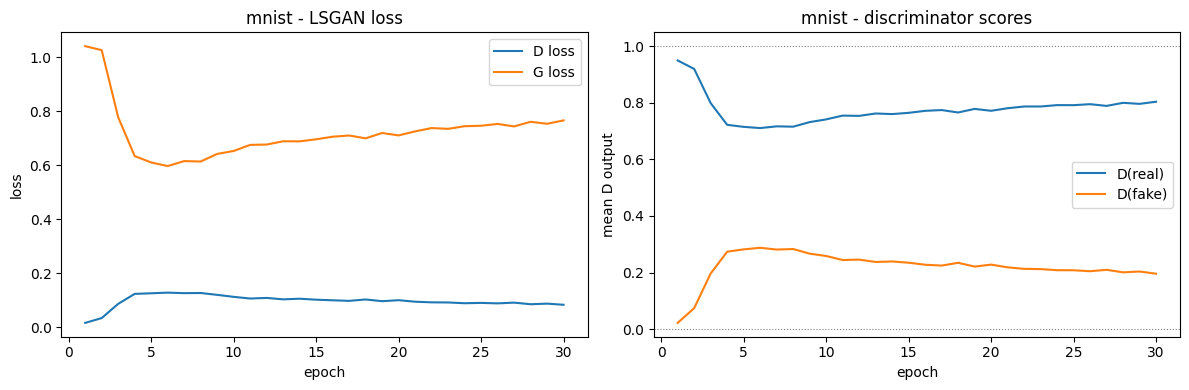

In [ ]:
if __name__ == "__main__":
    G_mnist, D_mnist, losses_mnist = train_lsgan(mnist_train_dl, "mnist")
    plot_gan_losses(losses_mnist, "mnist")

In [ ]:
if __name__ == "__main__":
    fid_mnist = run_fid(G_mnist, mnist_train_dl, "mnist")

    G_mnist.eval()
    with torch.no_grad():
        z = torch.randn(32, LATENT_DIM, device=device)
        samples = G_mnist(z).cpu() * 0.5 + 0.5
    save_image(samples,
               Path("runs") / "mnist" / "final_grid_32.png",
               nrow=8, padding=2, pad_value=1.0)
    print("Saved runs/mnist/final_grid_32.png")

[mnist] computing FID on 59904 real + 59904 fake samples...


Computing activations from real samples: 468it [19:21,  2.48s/it]
Computing activations from fake samples: 936it [19:25,  1.24s/it]


[mnist] FID = 4.6662
Saved runs/mnist/final_grid_32.png
